## 5. Perfil glicêmico

### Objetivo

Esta seção tem como objetivo caracterizar o perfil glicêmico dos participantes a partir das medidas de **hemoglobina glicada (HbA1c)** e **glicose em jejum** disponíveis no NHANES.

A HbA1c fornece informação sobre os níveis médios de glicose no sangue ao longo dos meses anteriores ao exame e está disponível para os participantes da base CORE. A glicose em jejum, por sua vez, está disponível apenas para uma subamostra específica e será analisada separadamente.

Além de caracterizar a distribuição dessas medidas, será investigada a relação entre a HbA1c e o histórico informado de diabetes. O objetivo é compreender como a informação autorreferida se relaciona com a medida laboratorial, sem assumir que ambas sejam equivalentes ou suficientes, isoladamente, para estabelecer um diagnóstico.

Importação das bibliotecas

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [7]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Identidade visual do HealthSync
COR_PRINCIPAL = "#0E766D"
COR_SECUNDARIA = "#10B981"
COR_TERCIARIA = "#14B8A6"

COR_DESTAQUE = "#F28C82"
COR_NEUTRA = "#94A3B8"

# Cores consistentes para respostas binárias
COR_SIM = COR_PRINCIPAL
COR_NAO = COR_NEUTRA

plt.rcParams["figure.figsize"] = (10, 6)

plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

plt.rcParams["figure.dpi"] = 120

Abrindo o csv, e testando se carregou corretamente

In [8]:
CAMINHO_CORE = "../dataset/healthsync_nhanes_2021_2023_core.csv"

df = pd.read_csv(CAMINHO_CORE)
display(df.head())

,id_participante,peso_estatistico_mec,peso_estatistico_entrevista,psu,estrato_amostral,idade,sexo,imc,pressao_sistolica,pressao_diastolica,...,glicose_jejum,colesterol_total,diabetes_informado,hipertensao_informada,hipertensao_2consultas,colesterol_alto_informado,medicamento_pressao,atv_moderada_min_semana,atv_vigorosa_min_semana,minutos_sedentarios_dia
0,130378.0,54.374.463.898,50.055.450.807,2.0,173.0,43.0,Homem,27.0,132.7,96.0,...,113.0,264.0,Nao,1.0,1.0,0.0,1.0,135.0,135.0,360.0
1,130379.0,34.084.721.548,29.087.450.605,2.0,173.0,66.0,Homem,33.5,117.0,78.7,...,99.0,214.0,Nao,1.0,1.0,0.0,1.0,180.0,135.0,480.0
2,130380.0,81.196.277.992,80.062.674.301,1.0,174.0,44.0,Mulher,29.7,109.0,78.3,...,156.0,187.0,Sim,0.0,NaN,1.0,NaN,20.0,0.0,240.0
3,130386.0,3.998.845.294,3.099.528.261,1.0,179.0,34.0,Homem,30.2,115.0,73.7,...,100.0,183.0,Nao,0.0,NaN,0.0,NaN,30.0,6.9,180.0
4,130387.0,2.077.625.485,19.896.970.559,1.0,181.0,68.0,Mulher,42.6,141.3,76.0,...,NaN,203.0,Nao,1.0,1.0,1.0,1.0,0.0,0.0,1200.0


### 5.1 Distribuição da HbA1c

**Pergunta da análise:** como os valores de HbA1c estão distribuídos entre os participantes da amostra?

Antes de investigar sua relação com outras características, é importante compreender a tendência central, a dispersão e o formato da distribuição da HbA1c.

Para isso, são utilizadas inicialmente estatísticas descritivas e um histograma, que permite visualizar a concentração dos valores ao longo da amostra.

In [9]:
resumo_hba1c = df["hba1c"].describe().round(2)

display(resumo_hba1c)

print(
    f"Valores ausentes: {df['hba1c'].isna().sum()} "
    f"({df['hba1c'].isna().mean() * 100:.2f}%)"
)

count    5283.00
mean        5.78
std         1.11
min         3.20
25%         5.20
50%         5.50
75%         5.90
max        17.10
Name: hba1c, dtype: float64

Valores ausentes: 0 (0.00%)


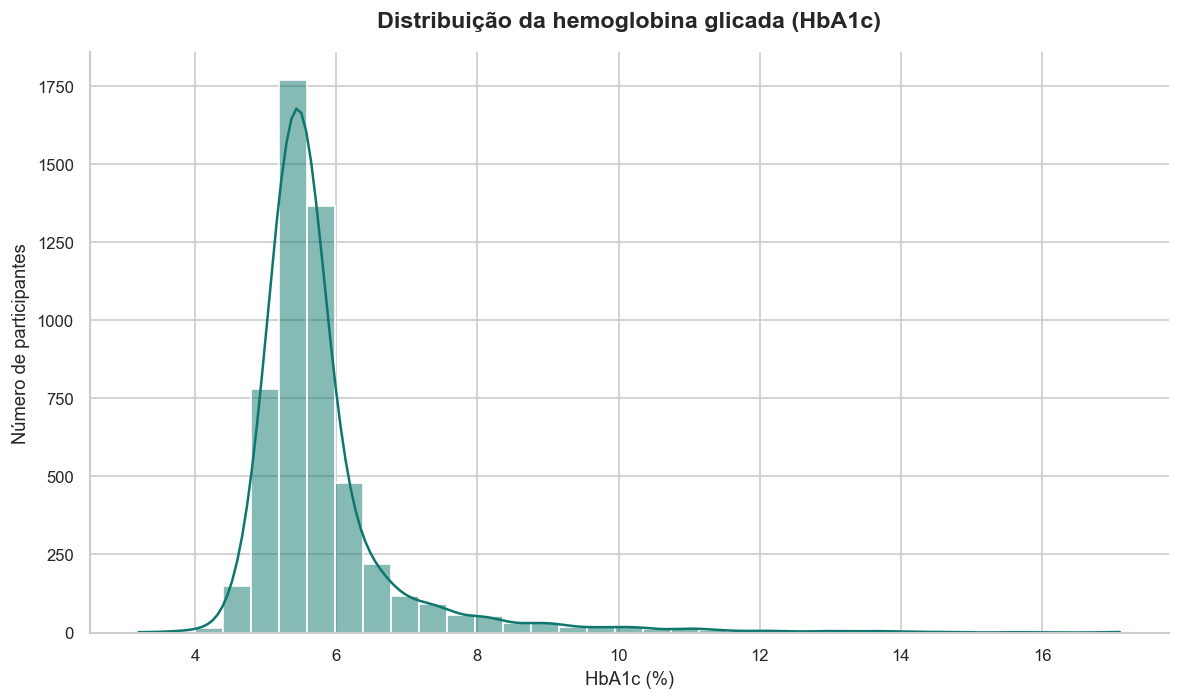

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="hba1c",
    bins=35,
    kde=True,
    color=COR_PRINCIPAL,
    edgecolor="white"
)

plt.title(
    "Distribuição da hemoglobina glicada (HbA1c)",
    pad=15,
    weight="bold"
)

plt.xlabel("HbA1c (%)")
plt.ylabel("Número de participantes")

sns.despine()

plt.tight_layout()
plt.show()

A HbA1c apresentou média de **5,78%** e mediana de **5,50%**, com metade dos participantes apresentando valores entre **5,20% e 5,90%**.

O histograma mostra maior concentração dos participantes nos valores mais baixos da distribuição e uma extensão em direção aos valores mais elevados, caracterizando uma distribuição assimétrica à direita.

Essa assimetria também ajuda a explicar a média superior à mediana, uma vez que valores elevados influenciam a média de forma mais intensa.

### 5.2 Valores extremos de HbA1c

**Objetivo:** verificar a presença de observações afastadas da região central da distribuição e avaliar se existem indícios suficientes para tratá-las como problemas nos dados.

O boxplot complementa o histograma ao representar a mediana, os quartis e observações mais afastadas da distribuição.

É importante destacar que um valor identificado visualmente como extremo não representa automaticamente um erro. Por esse motivo, essas observações serão inicialmente preservadas e inspecionadas antes de qualquer decisão de tratamento.

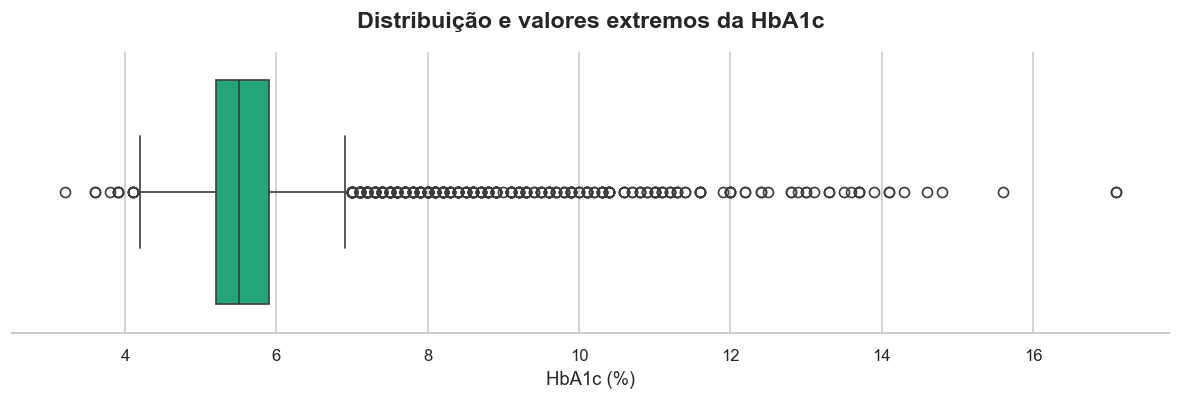

In [11]:
plt.figure(figsize=(10, 3.5))

sns.boxplot(
    data=df,
    x="hba1c",
    color=COR_SECUNDARIA
)

plt.title(
    "Distribuição e valores extremos da HbA1c",
    pad=15,
    weight="bold"
)

plt.xlabel("HbA1c (%)")
plt.ylabel("")

sns.despine(left=True)

plt.tight_layout()
plt.show()

In [12]:
maiores_hba1c = (
    df[
        [
            "id_participante",
            "idade",
            "sexo",
            "imc",
            "hba1c",
            "diabetes_informado"
        ]
    ]
    .sort_values(
        "hba1c",
        ascending=False
    )
    .head(20)
)

display(maiores_hba1c)

,id_participante,idade,sexo,imc,hba1c,diabetes_informado
1410,133541.0,46.0,Mulher,36.6,17.1,Sim
3168,137535.0,58.0,Mulher,30.3,17.1,Nao
3523,138311.0,31.0,Homem,44.4,15.6,Sim
2261,135544.0,67.0,Mulher,31.2,14.8,Sim
791,132155.0,25.0,Mulher,48.0,14.6,Sim
3886,139144.0,60.0,Homem,28.2,14.3,Sim
1458,133645.0,58.0,Homem,22.3,14.1,Sim
3444,138126.0,65.0,Homem,33.1,14.1,Sim
3650,138619.0,53.0,Homem,35.6,13.9,Sim
1935,134794.0,64.0,Mulher,38.6,13.7,Sim


A HbA1c variou entre **3,20% e 17,10%**, sendo observados alguns participantes com valores consideravelmente acima da região de maior concentração da distribuição.

A inspeção dos maiores valores confirma a presença de observações elevadas, incluindo participantes que informaram diabetes e também alguns que não informaram a condição ou foram classificados como "Borderline" no questionário.

Esses valores foram mantidos na análise. A identificação visual de uma observação extrema não é suficiente para classificá-la como erro de registro, e diferenças entre a medida laboratorial e o histórico informado serão analisadas separadamente.

### 5.3 HbA1c × diabetes informado

**Pergunta da análise:** a distribuição da HbA1c difere entre participantes segundo o histórico informado de diabetes?

Até este ponto, a HbA1c foi analisada independentemente das demais informações. Nesta etapa, a medida laboratorial é comparada com a resposta do participante sobre diabetes.

O objetivo não é verificar ou confirmar diagnósticos, mas observar se os grupos definidos pelo histórico informado apresentam diferenças na distribuição da HbA1c.

In [13]:
resumo_hba1c_diabetes = (
    df
    .groupby(
        "diabetes_informado",
        observed=True
    )["hba1c"]
    .agg(
        participantes="count",
        media="mean",
        mediana="median",
        desvio_padrao="std"
    )
    .round(2)
)

display(resumo_hba1c_diabetes)

,participantes,media,mediana,desvio_padrao
diabetes_informado,,,,
Borderline,186,6.10,5.9,1.05
Nao,4360,5.48,5.4,0.57
Sim,737,7.49,7.0,1.77


O boxplot permite comparar simultaneamente a mediana, a dispersão e a sobreposição dos valores de HbA1c entre as categorias **Não**, **Borderline** e **Sim**.

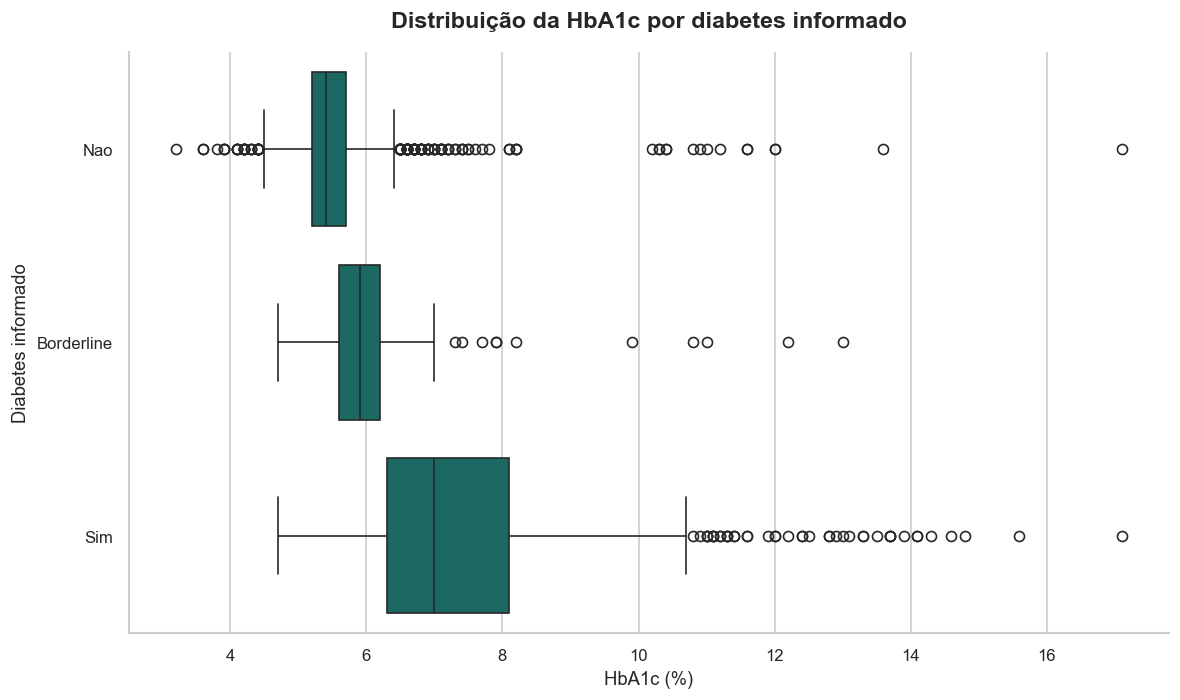

In [14]:
ordem_diabetes = [
    "Nao",
    "Borderline",
    "Sim"
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    y="diabetes_informado",
    x="hba1c",
    order=ordem_diabetes,
    color=COR_PRINCIPAL
)

plt.title(
    "Distribuição da HbA1c por diabetes informado",
    pad=15,
    weight="bold"
)

plt.xlabel("HbA1c (%)")
plt.ylabel("Diabetes informado")

sns.despine()

plt.tight_layout()
plt.show()

Foram observadas diferenças na distribuição da HbA1c entre as categorias de diabetes informado.

Os participantes que informaram diabetes apresentaram média de **7,49%** e mediana de **7,00%**, enquanto aqueles que não informaram diabetes apresentaram média de **5,48%** e mediana de **5,40%**. O grupo classificado como "Borderline" apresentou valores intermediários, com média de **6,10%** e mediana de **5,90%**.

Apesar dessas diferenças, existe sobreposição entre as distribuições, mostrando que o histórico informado e a HbA1c não representam informações perfeitamente equivalentes.

Os resultados indicam uma associação descritiva entre o histórico informado de diabetes e a medida laboratorial de HbA1c, sem permitir estabelecer relação causal ou confirmar individualmente a condição clínica dos participantes.

### 5.4 Faixas analíticas de HbA1c

Além da análise da HbA1c como variável contínua, são utilizadas faixas analíticas para facilitar a descrição da distribuição dos participantes.

Para adultos não gestantes, são considerados nesta análise os seguintes pontos de corte:

- **< 5,7%**
- **5,7% a 6,4%**
- **≥ 6,5%**

A utilização desses pontos de corte deverá ser acompanhada da respectiva referência clínica na documentação final do projeto.

In [15]:
faixas_hba1c = [
    0,
    5.7,
    6.5,
    np.inf
]

labels_hba1c = [
    "< 5,7%",
    "5,7–6,4%",
    "≥ 6,5%"
]

df["faixa_hba1c"] = pd.cut(
    df["hba1c"],
    bins=faixas_hba1c,
    labels=labels_hba1c,
    right=False
)

distribuicao_hba1c = (
    df["faixa_hba1c"]
    .value_counts(sort=False)
    .rename_axis("faixa_hba1c")
    .reset_index(name="quantidade")
)

distribuicao_hba1c["percentual"] = (
    distribuicao_hba1c["quantidade"]
    / distribuicao_hba1c["quantidade"].sum()
    * 100
)

distribuicao_hba1c["percentual"] = (
    distribuicao_hba1c["percentual"]
    .round(1)
)

display(distribuicao_hba1c)

,faixa_hba1c,quantidade,percentual
0,"< 5,7%",3196,60.5
1,"5,7–6,4%",1428,27.0
2,"≥ 6,5%",659,12.5


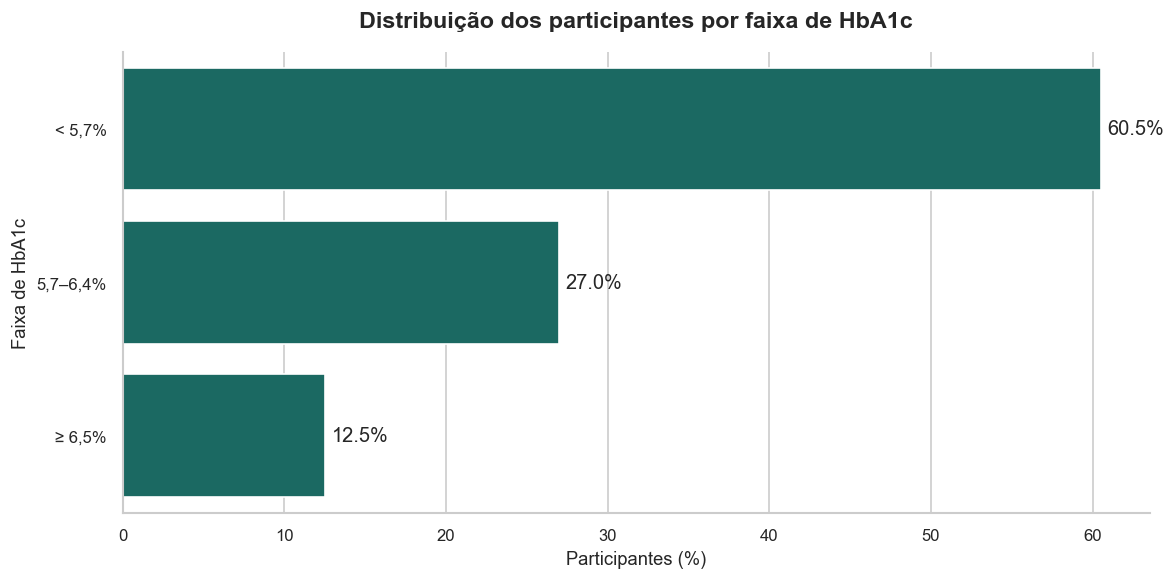

In [16]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=distribuicao_hba1c,
    y="faixa_hba1c",
    x="percentual",
    color=COR_PRINCIPAL
)

plt.title(
    "Distribuição dos participantes por faixa de HbA1c",
    pad=15,
    weight="bold"
)

plt.xlabel("Participantes (%)")
plt.ylabel("Faixa de HbA1c")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=4
    )

sns.despine()

plt.tight_layout()
plt.show()

Considerando as faixas analíticas utilizadas nesta EDA, **60,5%** dos participantes apresentaram HbA1c abaixo de 5,7%, **27,0%** apresentaram valores entre 5,7% e 6,4% e **12,5%** apresentaram HbA1c igual ou superior a 6,5%.

A maior parte da amostra encontra-se, portanto, na primeira faixa considerada, enquanto proporções menores aparecem nas duas faixas superiores.

### 5.5 Faixas de HbA1c × diabetes informado

**Pergunta da análise:** como as faixas analíticas de HbA1c estão distribuídas entre participantes com diferentes históricos informados de diabetes?

A análise anterior mostrou diferenças nas distribuições contínuas de HbA1c. Nesta etapa, o cruzamento entre as categorias permite observar essas diferenças em termos de proporções.

Os percentuais são calculados dentro de cada categoria de diabetes informado. Dessa forma, cada linha da tabela percentual representa aproximadamente 100% dos participantes daquela categoria.

In [17]:
tabela_hba1c_diabetes = pd.crosstab(
    df["diabetes_informado"],
    df["faixa_hba1c"]
)

display(tabela_hba1c_diabetes)

faixa_hba1c,"< 5,7%","5,7–6,4%","≥ 6,5%"
diabetes_informado,,,
Borderline,52,104,30
Nao,3089,1161,110
Sim,55,163,519


In [18]:
tabela_hba1c_diabetes_pct = pd.crosstab(
    df["diabetes_informado"],
    df["faixa_hba1c"],
    normalize="index"
).mul(100).round(1)

display(tabela_hba1c_diabetes_pct)

faixa_hba1c,"< 5,7%","5,7–6,4%","≥ 6,5%"
diabetes_informado,,,
Borderline,28.0,55.9,16.1
Nao,70.8,26.6,2.5
Sim,7.5,22.1,70.4


Entre os participantes que **não informaram diabetes**, 70,8% apresentaram HbA1c abaixo de 5,7%, 26,6% ficaram entre 5,7% e 6,4% e 2,5% apresentaram valores iguais ou superiores a 6,5%.

No grupo classificado como **Borderline**, a maior proporção, 55,9%, concentrou-se entre 5,7% e 6,4%, enquanto 16,1% apresentaram HbA1c igual ou superior a 6,5%.

Entre os participantes que **informaram diabetes**, 70,4% apresentaram HbA1c igual ou superior a 6,5%, enquanto 22,1% ficaram entre 5,7% e 6,4% e 7,5% abaixo de 5,7%.

Os resultados mostram uma associação entre o histórico informado e as faixas de HbA1c, mas também evidenciam combinações distintas entre as duas informações.

Essas diferenças não devem ser interpretadas automaticamente como diagnósticos não identificados, diagnósticos incorretos ou erros nos dados. A análise não dispõe do histórico clínico completo necessário para estabelecer essas conclusões.

### 5.6 Glicose em jejum — subamostra FASTING

**Pergunta da análise:** como a glicose em jejum está distribuída entre os participantes para os quais essa medida está disponível?

Diferentemente da HbA1c, a glicose em jejum não está disponível para todos os participantes da base CORE. O exame pertence a uma subamostra específica do NHANES.

Por esse motivo, esta análise utiliza separadamente a base **FASTING**, composta por **2.955 participantes**, evitando excluir da base principal indivíduos que não participaram desse componente específico do exame.

São utilizados histograma e boxplot para avaliar o formato da distribuição, sua tendência central, dispersão e presença de valores extremos.

In [20]:
CAMINHO_FASTING = "../dataset/healthsync_nhanes_2021_2023_fasting.csv"

df_fasting = pd.read_csv(CAMINHO_FASTING)

print(
    f"Participantes na base FASTING: "
    f"{df_fasting.shape[0]}"
)

Participantes na base FASTING: 2955


In [21]:
display(
    df_fasting["glicose_jejum"]
    .describe()
    .round(2)
)

count    2955.00
mean      109.67
std        34.31
min        59.00
25%        94.00
50%       101.00
75%       111.00
max       561.00
Name: glicose_jejum, dtype: float64

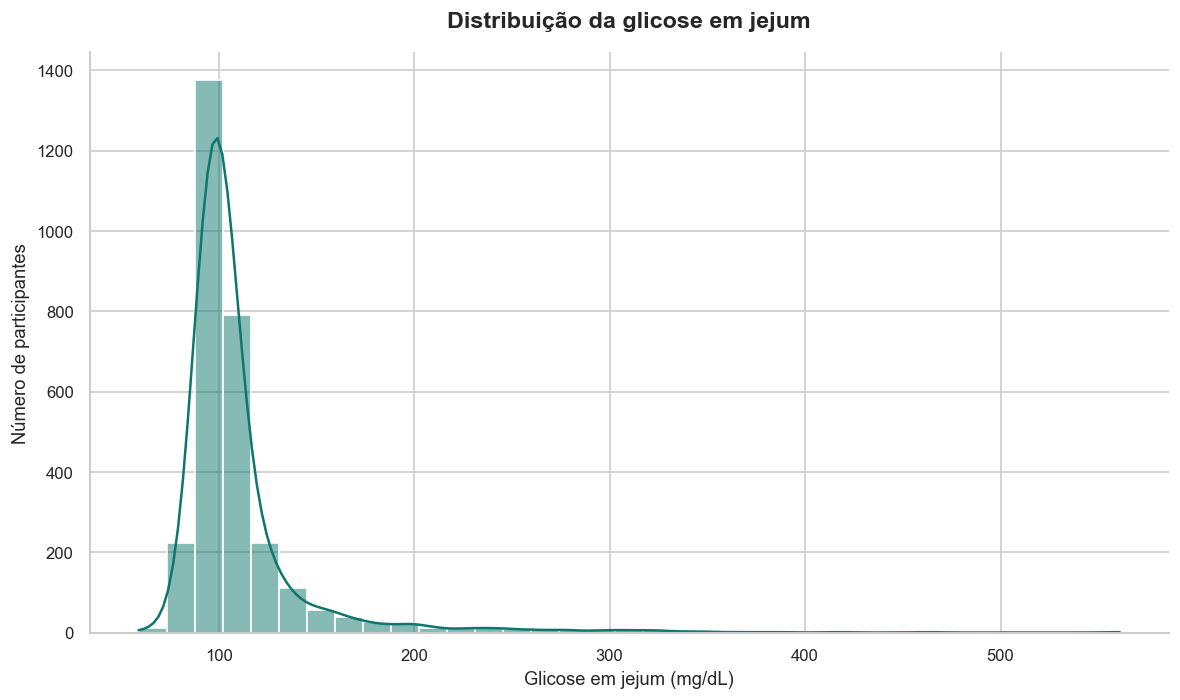

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_fasting,
    x="glicose_jejum",
    bins=35,
    kde=True,
    color=COR_PRINCIPAL,
    edgecolor="white"
)

plt.title(
    "Distribuição da glicose em jejum",
    pad=15,
    weight="bold"
)

plt.xlabel("Glicose em jejum (mg/dL)")
plt.ylabel("Número de participantes")

sns.despine()

plt.tight_layout()
plt.show()

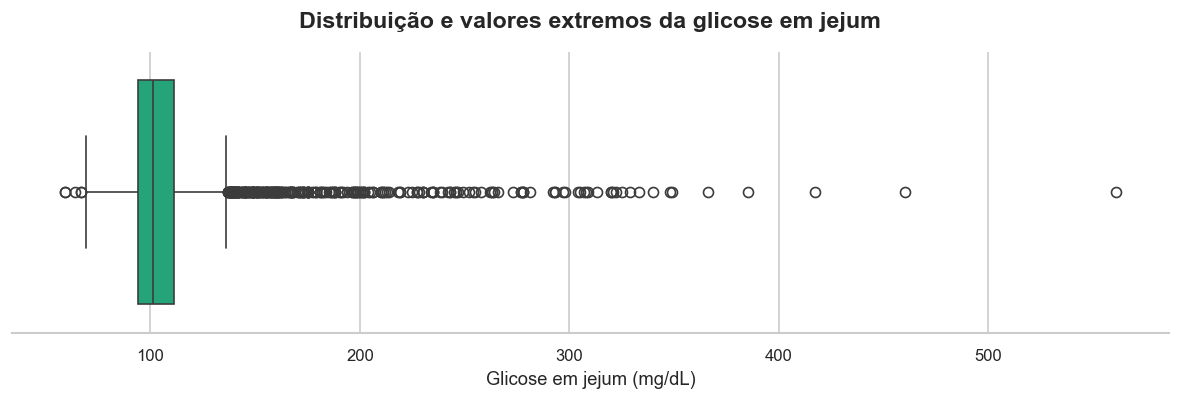

In [23]:
plt.figure(figsize=(10, 3.5))

sns.boxplot(
    data=df_fasting,
    x="glicose_jejum",
    color=COR_SECUNDARIA
)

plt.title(
    "Distribuição e valores extremos da glicose em jejum",
    pad=15,
    weight="bold"
)

plt.xlabel("Glicose em jejum (mg/dL)")
plt.ylabel("")

sns.despine(left=True)

plt.tight_layout()
plt.show()

Na subamostra FASTING, a glicose em jejum apresentou média de **109,67 mg/dL** e mediana de **101 mg/dL**. Metade dos participantes apresentou valores entre **94 e 111 mg/dL**, enquanto os valores observados variaram entre **59 e 561 mg/dL**.

Assim como observado para a HbA1c, a distribuição apresenta assimetria à direita, com maior concentração em valores mais baixos e uma parcela menor de observações elevadas.

Os valores extremos foram preservados nesta etapa, pois sua posição na distribuição não é suficiente para classificá-los automaticamente como erros.

A diferença entre o número de participantes das análises de HbA1c e glicose em jejum decorre do desenho de coleta do NHANES e da utilização de uma subamostra específica para o exame de glicose em jejum. Portanto, essa diferença não deve ser interpretada simplesmente como perda de dados da base CORE.

### 5.7 Síntese do perfil glicêmico

A análise do perfil glicêmico mostrou que a HbA1c apresenta distribuição assimétrica à direita, com maior concentração dos participantes em valores mais baixos e presença de observações elevadas.

Foram observadas diferenças na distribuição da HbA1c segundo o histórico informado de diabetes. Participantes que informaram diabetes apresentaram, em geral, valores mais elevados, enquanto aqueles que não informaram a condição apresentaram maior concentração nas faixas inferiores. Entretanto, também foram observadas combinações distintas entre histórico informado e medida laboratorial, reforçando que essas informações não devem ser tratadas como equivalentes.

A glicose em jejum apresentou comportamento igualmente assimétrico, mas sua análise foi realizada em uma subamostra específica devido ao desenho de coleta do NHANES.

Esses resultados caracterizam o perfil glicêmico da amostra e fornecem informações importantes para as etapas posteriores da análise.